# Naive Bayes + ROC-AUC + Class Imbalance

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Gaussian Naive Bayes

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

In [5]:
cancer=load_breast_cancer(as_frame=True)
x=cancer.data
# Original dataset:
# 0 = malignant
# 1 = benign
#
# Remap so the important disease class becomes positive:
# 1 = malignant
# 0 = benign
y=(cancer.target==0).astype(int)
print("Feature Shape:",x.shape)
print("Target Distribution")
print(y.value_counts())
X_train,X_test,y_train,y_test=train_test_split(
     x,
     y,
     test_size=0.20,
     random_state=42,
     stratify=y
)
model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        zero_division=0
    )
)

Feature Shape: (569, 30)
Target Distribution
target
0    357
1    212
Name: count, dtype: int64
              precision    recall  f1-score   support

      Benign       0.91      1.00      0.95        72
   Malignant       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



In [6]:
probabilities = model.predict_proba(X_test)
print("Known Classes:")
print(model.classes_)
probability_df = pd.DataFrame(
    probabilities,
    columns=[
        "Probability_Benign",
        "Probability_Malignant"
    ],
    index=X_test.index
)
results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = y_pred
results = pd.concat(
    [results, probability_df],
    axis=1
)
print(
    results[
        [
            "Actual",
            "Predicted",
            "Probability_Benign",
            "Probability_Malignant"
        ]
    ].head()
)

Known Classes:
[0 1]
     Actual  Predicted  Probability_Benign  Probability_Malignant
120       0          0        1.000000e+00           3.755128e-15
250       1          1       1.543564e-111           1.000000e+00
375       0          0        9.841114e-01           1.588857e-02
99        1          0        9.967978e-01           3.202246e-03
455       0          0        1.000000e+00           2.929225e-10


## Multinomial Naive Bayes

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

messages = [
    "win free money now",
    "limited offer claim prize",
    "congratulations you are a winner",
    "free gift click this link",
    "urgent claim your reward",
    "exclusive money making offer",
    "project meeting at ten",
    "please review the report",
    "team standup tomorrow morning",
    "submit the assignment today",
    "your interview is scheduled",
    "let us discuss the project"
]

# 1 = spam
# 0 = not spam
labels = [
    1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0
]

multinomial_model = Pipeline(steps=[
    (
        "vectorizer",
        CountVectorizer()
    ),
    (
        "classifier",
        MultinomialNB(alpha=1.0)
    )
])

multinomial_model.fit(
    messages,
    labels
)

new_messages = [
    "claim your free prize",
    "project meeting tomorrow"
]

predictions = multinomial_model.predict(
    new_messages
)

probabilities = multinomial_model.predict_proba(
    new_messages
)

for message, prediction, probability in zip(
    new_messages,
    predictions,
    probabilities
):
    label = (
        "Spam"
        if prediction == 1
        else "Not Spam"
    )

    print("\nMessage:", message)
    print("Prediction:", label)
    print(
        "Spam probability:",
        probability[1]
    )


Message: claim your free prize
Prediction: Spam
Spam probability: 0.9473684210526324

Message: project meeting tomorrow
Prediction: Not Spam
Spam probability: 0.07692307692307682


## Bernoulli Naive Bayes

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline

bernoulli_model = Pipeline(steps=[
    (
        "vectorizer",
        CountVectorizer(binary=True)
    ),
    (
        "classifier",
        BernoulliNB(alpha=1.0)
    )
])

bernoulli_model.fit(
    messages,
    labels
)

new_messages = [
    "free free free prize",
    "project review meeting"
]

predictions = bernoulli_model.predict(
    new_messages
)

probabilities = bernoulli_model.predict_proba(
    new_messages
)

for message, prediction, probability in zip(
    new_messages,
    predictions,
    probabilities
):
    print("\nMessage:", message)

    print(
        "Prediction:",
        "Spam" if prediction == 1
        else "Not Spam"
    )

    print(
        "Spam probability:",
        probability[1]
    )


Message: free free free prize
Prediction: Spam
Spam probability: 0.9084648797542115

Message: project review meeting
Prediction: Not Spam
Spam probability: 0.04241025989007271


## ROC-AUC Code

### Gaussian Naive Bayes

ROC-AUC: 0.9933862433862434


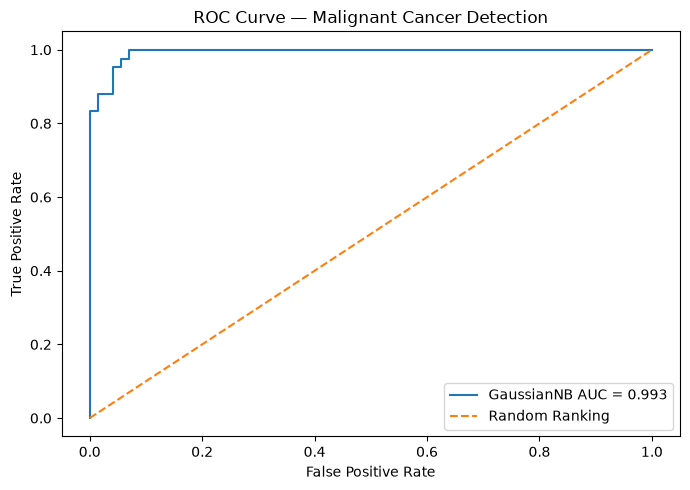

In [9]:
from sklearn.metrics import (
     roc_curve,
     roc_auc_score
)
pos_sc=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,pos_sc)
auc_sc=roc_auc_score(y_test,pos_sc)
print("ROC-AUC:", auc_sc)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"GaussianNB AUC = {auc_sc:.3f}"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Ranking"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Malignant Cancer Detection")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
roc_table=pd.DataFrame({
     "Threshold":thresholds,
     "False_positive_rate":fpr,
     "True_positive_rate":tpr
})
print(roc_table.head())

   Threshold  False_positive_rate  True_positive_rate
0        inf             0.000000            0.000000
1   1.000000             0.000000            0.595238
2   0.997009             0.000000            0.833333
3   0.497353             0.013889            0.833333
4   0.019669             0.013889            0.880952


In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_imbalanced, y_imbalanced = make_classification(
    n_samples=3000,
    n_features=12,
    n_informative=7,
    n_redundant=3,
    n_classes=2,
    weights=[0.95, 0.05],
    class_sep=1.0,
    random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = (
    train_test_split(
        X_imbalanced,
        y_imbalanced,
        test_size=0.25,
        random_state=42,
        stratify=y_imbalanced
    )
)

print("Training Distribution:")
print(
    pd.Series(
        y_train_imb
    ).value_counts(normalize=True)
)

Training Distribution:
0    0.943111
1    0.056889
Name: proportion, dtype: float64


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_imb,y_train_imb)
dummy_pred = dummy_model.predict(X_test_imb)
print("Dummy Accuracy:",accuracy_score(
        y_test_imb,
        dummy_pred
))
print("Dummy Recall:",recall_score(
        y_test_imb,
        dummy_pred,
        zero_division=0
))
print("Dummy F1:",f1_score(
        y_test_imb,
        dummy_pred,
        zero_division=0
))

Dummy Accuracy: 0.944
Dummy Recall: 0.0
Dummy F1: 0.0


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
regular_model = Pipeline(steps=[
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression(
            max_iter=1000,
            random_state=42))
])
regular_model.fit(X_train_imb,y_train_imb)
regular_pred = regular_model.predict(X_test_imb)

In [14]:
balanced_model = Pipeline(steps=[
    ("scaler",StandardScaler()),
    ("classifier",LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42))
])
balanced_model.fit(X_train_imb,y_train_imb)
balanced_pred = balanced_model.predict(X_test_imb)

In [15]:
from sklearn.metrics import roc_auc_score
models = {
    "Regular Logistic Regression": regular_model,
    "Balanced Logistic Regression": balanced_model
}
comparison_rows = []
for name, fitted_model in models.items():
    predictions = fitted_model.predict(X_test_imb)
    scores = fitted_model.predict_proba(X_test_imb)[:, 1]
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test_imb,
            predictions
        ),
        "Precision": precision_score(
            y_test_imb,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_imb,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_imb,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test_imb,
            scores
        )
    })
comparison_df = pd.DataFrame(
    comparison_rows
)
comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Regular Logistic Regression,0.954667,0.833333,0.238095,0.370370,0.833602
1,Balanced Logistic Regression,0.809333,0.186335,0.714286,0.295567,0.839857


In [22]:
!pip install -q imbalanced-learn

In [24]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as imbPipeline
oversam_model=imbPipeline(steps=[
     ("scaler",StandardScaler()),
     ("sampler",RandomOverSampler(random_state=42)),
     ("classifier",LogisticRegression(
          max_iter=1000,
          random_state=42))
])
oversam_model.fit(X_train_imb,y_train_imb)
oversam_pred=oversam_model.predict(X_test_imb)

In [25]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
unsam_model=ImbPipeline(steps=[
     ("scaler",StandardScaler()),
     ("sampler",RandomUnderSampler(random_state=42)),
     ("classifier",LogisticRegression(
          max_iter=1000,random_state=42))
])
unsam_model.fit(X_train_imb,y_train_imb)
unsam_pred=unsam_model.predict(X_test_imb)

In [27]:
from sklearn.metrics import confusion_matrix
probab=balanced_model.predict_proba(X_test_imb)[:,1]
th_res=[]
for th in [0.20,0.30,0.40,0.50,0.60,0.70]:
    predictions = (probab >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_test_imb,
        predictions,
        labels=[0, 1]
    ).ravel()
    th_res.append({
        "Threshold": th,
        "Accuracy": accuracy_score(y_test_imb,predictions),
        "Precision": precision_score(
            y_test_imb,predictions,zero_division=0),
        "Recall": recall_score(
            y_test_imb,predictions,zero_division=0),
        "F1": f1_score(
            y_test_imb,predictions,zero_division=0),
        "FP": fp,
        "FN": fn
    })
th_df = pd.DataFrame(th_res)
th_df

,Threshold,Accuracy,Precision,Recall,F1,FP,FN
0,0.2,0.558667,0.101928,0.880952,0.182716,326,5
1,0.3,0.668000,0.129032,0.857143,0.224299,243,6
2,0.4,0.758667,0.160976,0.785714,0.267206,172,9
3,0.5,0.809333,0.186335,0.714286,0.295567,131,12
4,0.6,0.874667,0.250000,0.619048,0.356164,78,16
5,0.7,0.914667,0.338235,0.547619,0.418182,45,19


In [28]:
false_negative_cost = 10_000
false_positive_cost = 500
th_df["Business_Cost"] = (
    th_df["FN"]
    * false_negative_cost
    +
    th_df["FP"]
    * false_positive_cost
)
print(
    th_df.sort_values(
        "Business_Cost"
    )
)

   Threshold  Accuracy  Precision    Recall        F1   FP  FN  Business_Cost
2        0.4  0.758667   0.160976  0.785714  0.267206  172   9         176000
1        0.3  0.668000   0.129032  0.857143  0.224299  243   6         181500
3        0.5  0.809333   0.186335  0.714286  0.295567  131  12         185500
4        0.6  0.874667   0.250000  0.619048  0.356164   78  16         199000
5        0.7  0.914667   0.338235  0.547619  0.418182   45  19         212500
0        0.2  0.558667   0.101928  0.880952  0.182716  326   5         213000


In [29]:
from sklearn.metrics import classification_report

def evaluate_classifier(
    name,
    fitted_model,
    X_test,
    y_test,
    threshold=0.50
):
    probabilities = fitted_model.predict_proba(
        X_test
    )[:, 1]

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    metrics = {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    print("\n", name)
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    return metrics